# Strong coupling expansion
Compute the average denstity $$\langle n \rangle = -\frac{\partial}{\partial \mu} \Omega$$
where $\Omega = -k_BT \ln Z$.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import h5py
from robustpade import pade_approx_batch

## Atomic limit exact results for order 0 and 2 

In [40]:
def Z_atomic(U:float, beta:float, mu:float):
    return 1 + 2*np.exp(beta*mu) + np.exp(-beta*(U-2*mu))


def a_0(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)
    return -1/beta*np.log(Zat) # factor 2 for spin and


def a_2(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)
    return -2/beta*fact*(A+B)*4 #factor 2 for spin and 2 for sites!


U = 8.0


## Load files 

In [41]:
def load_data(U,beta, alpha):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_4_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_4 = f['mean_list'][:]
        errors_4 = f['error_list'][:]
    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_6_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        a_6 = f['mean_list'][:]
        errors_6 = f['error_list'][:]


    partial_sum_4 = a_0(U, beta, mus) + a_2(U, beta, mus) + a_4
    partial_sum_6 = partial_sum_4 + a_6


    n0 = -np.gradient(a_0(U, beta, mus), mus)
    n4 = -np.gradient(partial_sum_4, mus)
    n6 = -np.gradient(partial_sum_6, mus)

    return mus, n0, n4, n6, a_4, errors_4, a_6, errors_6

    


## Compare with CDet $U=8$, $\beta = 0.75$

In [42]:
U = 8.0
alpha = 0.001
mus, n0, n4, n6,_ ,_,_,_= load_data(U, beta=0.75, alpha=alpha)

In [43]:
Cdet = np.array([0.000000000000000000e+00, 6.577886434859689935e-01,
2.000000000000000111e-01, 6.830654739026462696e-01,
4.000000000000000222e-01, 7.076495052411750919e-01,
6.000000000000000888e-01, 7.314561757479093318e-01,
8.000000000000000444e-01, 7.544149325723877864e-01,
1.000000000000000000e+00, 7.764680082055557264e-01,
1.200000000000000178e+00, 7.975690887248386707e-01,
1.400000000000000133e+00, 8.176829680520789623e-01,
1.600000000000000089e+00, 8.367864676447966943e-01,
1.800000000000000044e+00, 8.548702023276939510e-01,
2.000000000000000000e+00, 8.719404788084273994e-01,
2.200000000000000178e+00, 8.880207016779730900e-01,
2.400000000000000355e+00, 9.031519434244016376e-01,
2.600000000000000089e+00, 9.173926215565577635e-01,
2.800000000000000266e+00, 9.308174158122632935e-01,
3.000000000000000000e+00, 9.435156370374528922e-01,
3.200000000000000178e+00, 9.555892585948051465e-01,
3.400000000000000355e+00, 9.671507808392967309e-01,
3.600000000000000089e+00, 9.783210477561885554e-01,
3.800000000000000266e+00, 9.892270864443353240e-01,
4.000000000000000000e+00, 9.999999999999955591e-01])

In [44]:
cdet_mus = Cdet[::2]
cdet_n = Cdet[1::2]

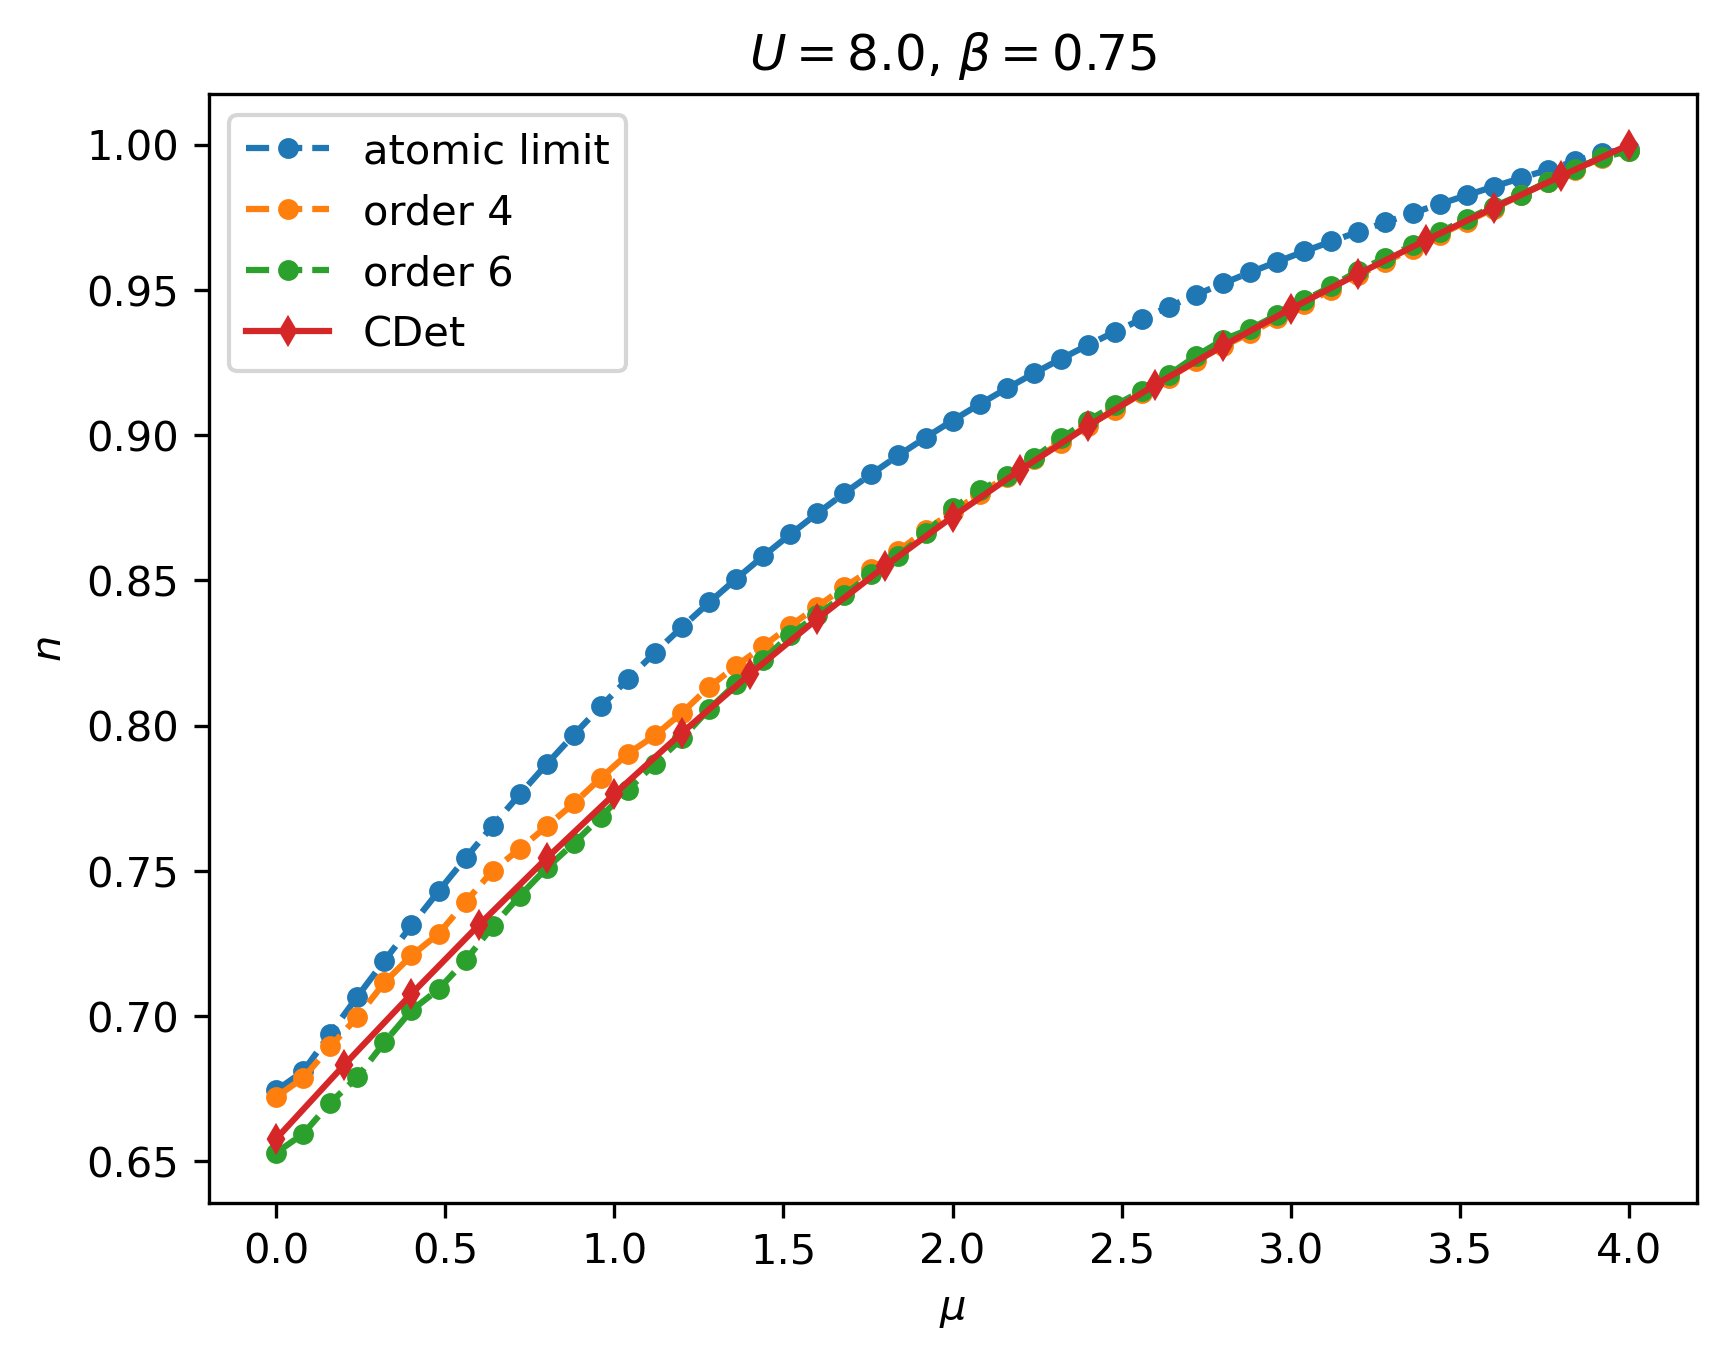

In [45]:
fig, ax = plt.subplots()
ax.plot(mus, n0, label='atomic limit', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(mus, n4, label='order 4', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(mus, n6, label='order 6', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(cdet_mus, cdet_n, label='CDet', marker = 'd', markersize=4)

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$n$')
ax.set_title(r'$U=8.0$, $\beta=0.75$')
ax.legend()

## Precise derivative

In [51]:
U = 8.0
beta = 2.0
alpha = 0.01
eps = 1e-2

In [59]:
def get_derivative(a, eps):
    a_minus = a[::2]
    a_plus = a[1::2]
    return (a_plus-a_minus)/(2*eps)

def load_density(U,beta, alpha, eps=1e-2):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_4_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_4 = f['mean_list'][:]
        errors_4 = f['error_list'][:]
    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_6_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        a_6 = f['mean_list'][:]
        errors_6 = f['error_list'][:]

    a_0_values = a_0(U, beta, mus)
    a_2_values = a_2(U, beta, mus) 

    da0dmu = get_derivative(a_0_values, eps)
    da2dmu = get_derivative(a_2_values, eps)
    da4dmu = get_derivative(a_4, eps)
    errors_4_dmu = np.sqrt((errors_4[::2]**2 + errors_4[1::2]**2))/(2*eps)
    da6dmu = get_derivative(a_6, eps)
    errors_6_dmu = np.sqrt((errors_6[::2]**2 + errors_6[1::2]**2))/(2*eps)

    print(mus)

    n0 = -da0dmu
    n4 = -(da0dmu + da2dmu + da4dmu)
    n6 = n4 - da6dmu

    mus_n = mus[::2]+eps # take every second element to get the original mu values

    return mus_n, n0, n4, n6, errors_4_dmu, errors_6_dmu

In [60]:
mus, n0, n4, n6, errors_4_dmu, errors_6_dmu = load_density(U, beta=beta, alpha=alpha)

[0.99 1.01 1.49 1.51 1.99 2.01 2.49 2.51 2.99 3.01]


In [61]:
errors_4_dmu, errors_6_dmu

(array([0.09139307, 0.03525551, 0.01529194, 0.01138152, 0.01200171]),
 array([0.19120511, 0.06249348, 0.02507614, 0.01157456, 0.00741556]))

In [62]:
n6

array([1.84408599, 0.86482085, 0.84831638, 0.91664646, 0.96283183])

In [63]:
cdet_mus = np.array([1.0, 1.5, 2.0])
cdet_n = np.array([0.761236, 0.838576, 0.905056])

In [64]:
n4

array([0.50108157, 0.61099882, 0.83519446, 0.93304052, 0.97167645])

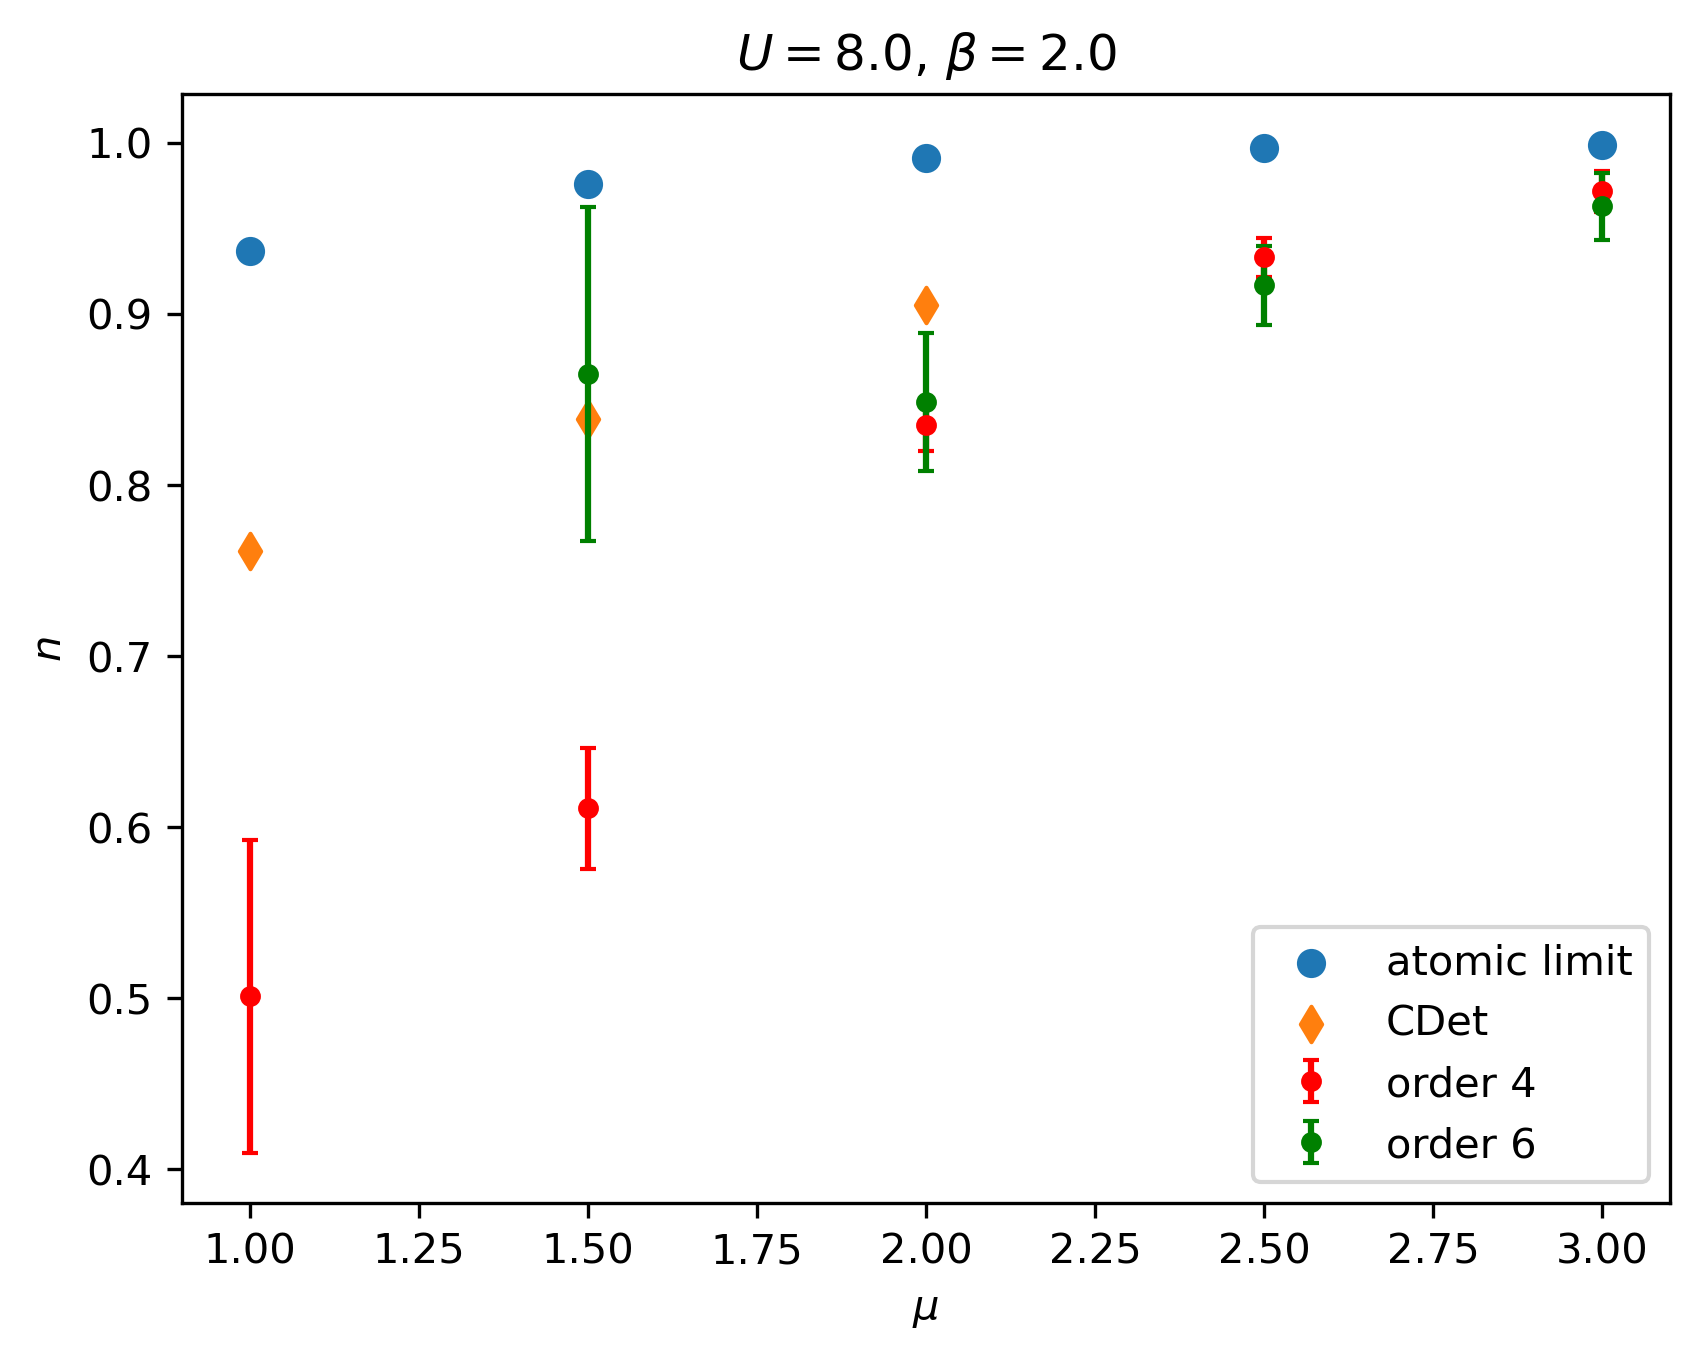

In [67]:
plt.scatter(mus, n0, label='atomic limit', marker = 'o')
plt.scatter(cdet_mus, cdet_n, label='CDet', marker = 'd')
plt.errorbar(mus, n4, yerr=errors_4_dmu, label='order 4', fmt='o', markersize=4, capsize=2, c='r')
plt.errorbar(mus[1:], n6[1:], yerr=(errors_6_dmu+errors_4_dmu)[1:], label='order 6', fmt='o', markersize=4, capsize=2, c='g')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$n$')
plt.title(r'$U=8.0$, $\beta=2.0$')
plt.legend()